# Day 1: Machine Learning & MLOps in Practice
## Session 1: Data Preparation & Initial Modeling

First, we install the necessary tools and download the Telco Customer Churn dataset.

In [31]:
!pip install pandas==2.2.2 scikit-learn==1.5.1 joblib==1.4.2 matplotlib==3.9.0 -q
!wget -q https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv -O telco_churn.csv
print("✅ Tools installed and data downloaded.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 52.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.1 which is incompatible.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.1 which is incompatible.
✅ Tools installed and data downloaded.


### 1.2 Loading and Inspecting the Data
We load the CSV and fix the `TotalCharges` column, which contains empty strings that cause it to be treated as text.

In [32]:
import pandas as pd
import numpy as np

df = pd.read_csv("telco_churn.csv")

# Technical fix: Convert TotalCharges to numeric and handle blanks
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)

# Drop ID column
df = df.drop(columns=["customerID"])

display(df.head())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1.6 Splitting the Data
We split the data into Training (80%) and Testing (20%) sets to ensure we have an honest way to grade the model.

In [33]:
from sklearn.model_selection import train_test_split

y = (df["Churn"] == "Yes").astype(int)
X = df.drop(columns=["Churn"])

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Data split: {len(X_train)} training, {len(X_test)} testing.")

Data split: 5634 training, 1409 testing.


### 1.7 Building the Pipeline
We package imputation, scaling, and encoding into a single `Pipeline` object.

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

numeric_steps = Pipeline(steps=[
    ("fill_missing", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

categorical_steps = Pipeline(steps=[
    ("fill_missing", SimpleImputer(strategy="most_frequent")),
    ("to_numbers", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("numbers", numeric_steps, numeric_features),
    ("categories", categorical_steps, categorical_features),
])

model = Pipeline(steps=[
    ("prepare", preprocessor),
    ("learn", LogisticRegression(max_iter=1000, random_state=42)),
])

model.fit(X_train, y_train)
print("Logistic Regression Pipeline trained.")

Logistic Regression Pipeline trained.


## Session 2: Model Comparison & Evaluation

Now we compare Logistic Regression against Random Forest and Gradient Boosting.

In [35]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

candidates = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42),
}

for name, algorithm in candidates.items():
    pipe = Pipeline(steps=[("prepare", preprocessor), ("learn", algorithm)])
    scores = cross_val_score(pipe, X_train, y_train, cv=5)
    print(f"{name:<22} Accuracy: {scores.mean():.3f} (+/- {scores.std():.3f})")

Logistic Regression    Accuracy: 0.804 (+/- 0.014)
Random Forest          Accuracy: 0.791 (+/- 0.011)
Gradient Boosting      Accuracy: 0.802 (+/- 0.014)


### 2.4 Confusion Matrix and Try Yourself Task
We evaluate the best model (Gradient Boosting) using a Confusion Matrix to see our 'Missed' vs 'False Alarms'.

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



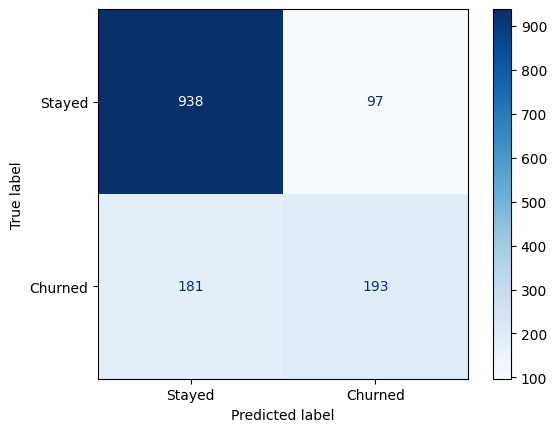

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

final_model = Pipeline(steps=[("prepare", preprocessor), ("learn", GradientBoostingClassifier(random_state=42))])
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Stayed", "Churned"], cmap="Blues")
plt.show()

## Session 3: MLOps - Saving and Loading
We save the model using `joblib` so it can be deployed.

In [37]:
import joblib

# Save the pipeline
joblib.dump(final_model, "churn_pipeline.pkl")

# Try yourself: Prediction function
def predict_new_customer(data_list):
    loaded_pipe = joblib.load("churn_pipeline.pkl")
    input_df = pd.DataFrame(data_list)
    pred = loaded_pipe.predict(input_df)
    prob = loaded_pipe.predict_proba(input_df)[:, 1]
    return "Churn" if pred[0] == 1 else "Stay", prob[0]

sample = [{
    "gender": "Female", "SeniorCitizen": 0, "Partner": "Yes", "Dependents": "No",
    "tenure": 2, "PhoneService": "Yes", "MultipleLines": "No",
    "InternetService": "Fiber optic", "OnlineSecurity": "No", "OnlineBackup": "No",
    "DeviceProtection": "No", "TechSupport": "No", "StreamingTV": "No",
    "StreamingMovies": "No", "Contract": "Month-to-month", "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check", "MonthlyCharges": 70.7, "TotalCharges": 151.65,
}]

print(f"Sample Prediction: {predict_new_customer(sample)}")

Sample Prediction: ('Churn', np.float64(0.6396679005246207))


## 📊 New Project: Census Income Prediction (>50K vs <=50K)

We will now apply our MLOps workflow to a new dataset. The goal is to predict if an individual's income exceeds $50,000 per year based on census data. This is a classic binary classification problem.

In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import joblib

# 1. Fetch the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
    "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
    "hours-per-week", "native-country", "income"
]
income_df = pd.read_csv(url, names=columns, sep=',\\s+', engine='python', na_values="?")

# 2. Data Preparation
# Drop fnlwgt as it's a weight assigned by the census bureau and not a personal feature
income_df = income_df.drop(columns=["fnlwgt"])

# Map target 'income' to 1 (>50K) and 0 (<=50K)
# Note: Data has a trailing dot in some versions, or leading spaces, we strip and map
y_income = income_df["income"].str.strip().map({"<=50K": 0, ">50K": 1})
X_income = income_df.drop(columns=["income"])

# Identify numeric and categorical columns
num_cols_inc = X_income.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_inc = X_income.select_dtypes(include=['object']).columns.tolist()

display(income_df.head())
print(f"Dataset loaded: {income_df.shape[0]} rows.")

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Dataset loaded: 32561 rows.


### Training the Income Prediction Pipeline
Just like the Telco project, we split the data and build a pipeline that handles missing census values (imputation), scales numeric counts, and one-hot encodes categorical labels like 'occupation' and 'workclass'.

In [39]:
# 3. Split the data
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_income, y_income, test_size=0.2, random_state=42, stratify=y_income
)

# 4. Define Pipeline Steps
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

prep_income = ColumnTransformer([
    ('num', num_transformer, num_cols_inc),
    ('cat', cat_transformer, cat_cols_inc)
])

# 5. Build and Test the Pipeline (Logistic Regression vs Gradient Boosting)
candidates_inc = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

for name, algo in candidates_inc.items():
    pipe_inc = Pipeline([('prep', prep_income), ('model', algo)])
    cv_scores = cross_val_score(pipe_inc, X_train_i, y_train_i, cv=5)
    print(f"{name} CV Accuracy: {cv_scores.mean():.3f}")

# 6. Save the Final Pipeline
final_income_model = Pipeline([('prep', prep_income), ('model', GradientBoostingClassifier(random_state=42))])
final_income_model.fit(X_train_i, y_train_i)
joblib.dump(final_income_model, "income_pipeline.pkl")
print("\n✅ Income prediction model saved as 'income_pipeline.pkl'")

Logistic Regression CV Accuracy: 0.850
Gradient Boosting CV Accuracy: 0.864

✅ Income prediction model saved as 'income_pipeline.pkl'


### 2.7 Final Evaluation on Adult Census Data
We now evaluate our final Gradient Boosting model on the held-out test set to confirm its performance.

--- Classification Report: Adult Census Income ---
              precision    recall  f1-score   support

       <=50K       0.89      0.95      0.92      4945
        >50K       0.79      0.62      0.70      1568

    accuracy                           0.87      6513
   macro avg       0.84      0.78      0.81      6513
weighted avg       0.86      0.87      0.86      6513



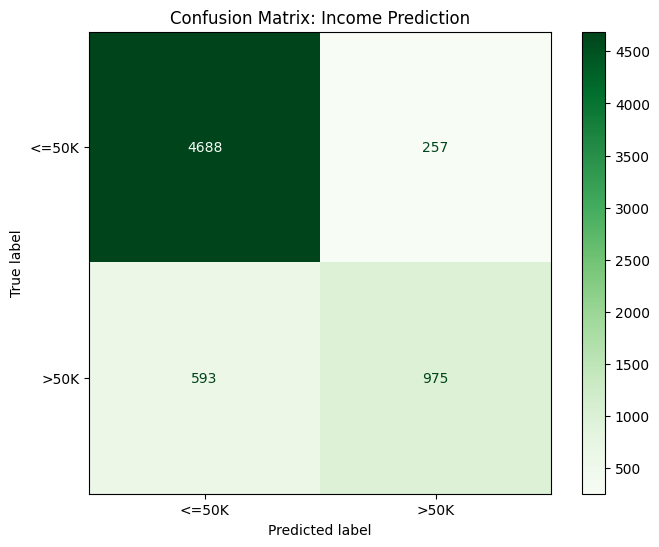

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Predict on the test set
y_pred_i = final_income_model.predict(X_test_i)

# Print metrics
print("--- Classification Report: Adult Census Income ---")
print(classification_report(y_test_i, y_pred_i, target_names=['<=50K', '>50K']))

# Display Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_i,
    y_pred_i,
    display_labels=["<=50K", ">50K"],
    cmap="Greens",
    ax=ax
)
plt.title("Confusion Matrix: Income Prediction")
plt.show()